In [ ]:
%load_ext cuml.accel

[2025-04-22 14:32:40.861] [CUML] [info] cuML: Installed accelerator for sklearn.
[2025-04-22 14:33:05.641] [CUML] [info] cuML: Installed accelerator for umap.
[2025-04-22 14:33:05.731] [CUML] [info] cuML: Installed accelerator for hdbscan.
[2025-04-22 14:33:05.731] [CUML] [info] cuML: Successfully initialized accelerator.


## **Importing dependencies**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import gc

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Shown246/CSE445_Datasets/refs/heads/main/Big_Five_Personality_Clustering_cleaned.csv')
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,1.0,2.0,...,1.0,5.0,4.0,5.0,3.0,6.0,4.0,2.0,5.0,3.0
1,2.0,5.0,2.0,4.0,4.0,5.0,2.0,3.0,1.0,3.0,...,4.0,5.0,5.0,5.0,3.0,6.0,4.0,4.0,3.0,3.0
2,3.0,4.0,4.0,5.0,4.0,5.0,2.0,4.0,3.0,3.0,...,5.0,6.0,5.0,6.0,3.0,6.0,5.0,4.0,5.0,2.0
3,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,...,5.0,5.0,4.0,4.0,4.0,6.0,5.0,5.0,4.0,4.0
4,3.0,4.0,2.0,4.0,3.0,5.0,4.0,4.0,3.0,2.0,...,5.0,6.0,5.0,6.0,5.0,6.0,5.0,5.0,5.0,5.0


# K means Clustering

In [ ]:
X = df.select_dtypes(include=['float64', 'int64'])
evaluation_results = []

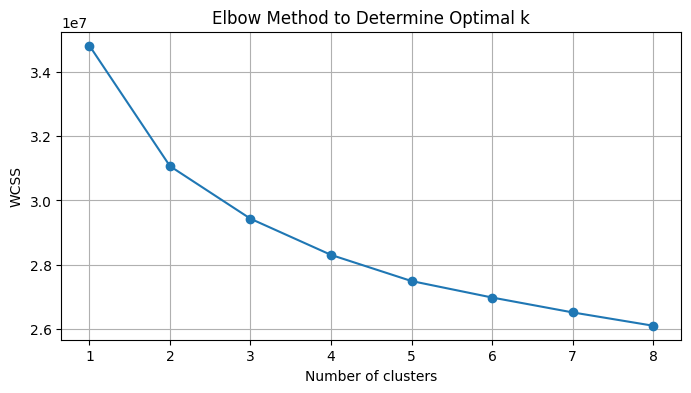

In [ ]:
wcss = []  # within-cluster sum of squares
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 9), wcss, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters
print(df['Cluster'].value_counts())

Cluster
1    132758
3    126155
2    122295
0    118792
Name: count, dtype: int64


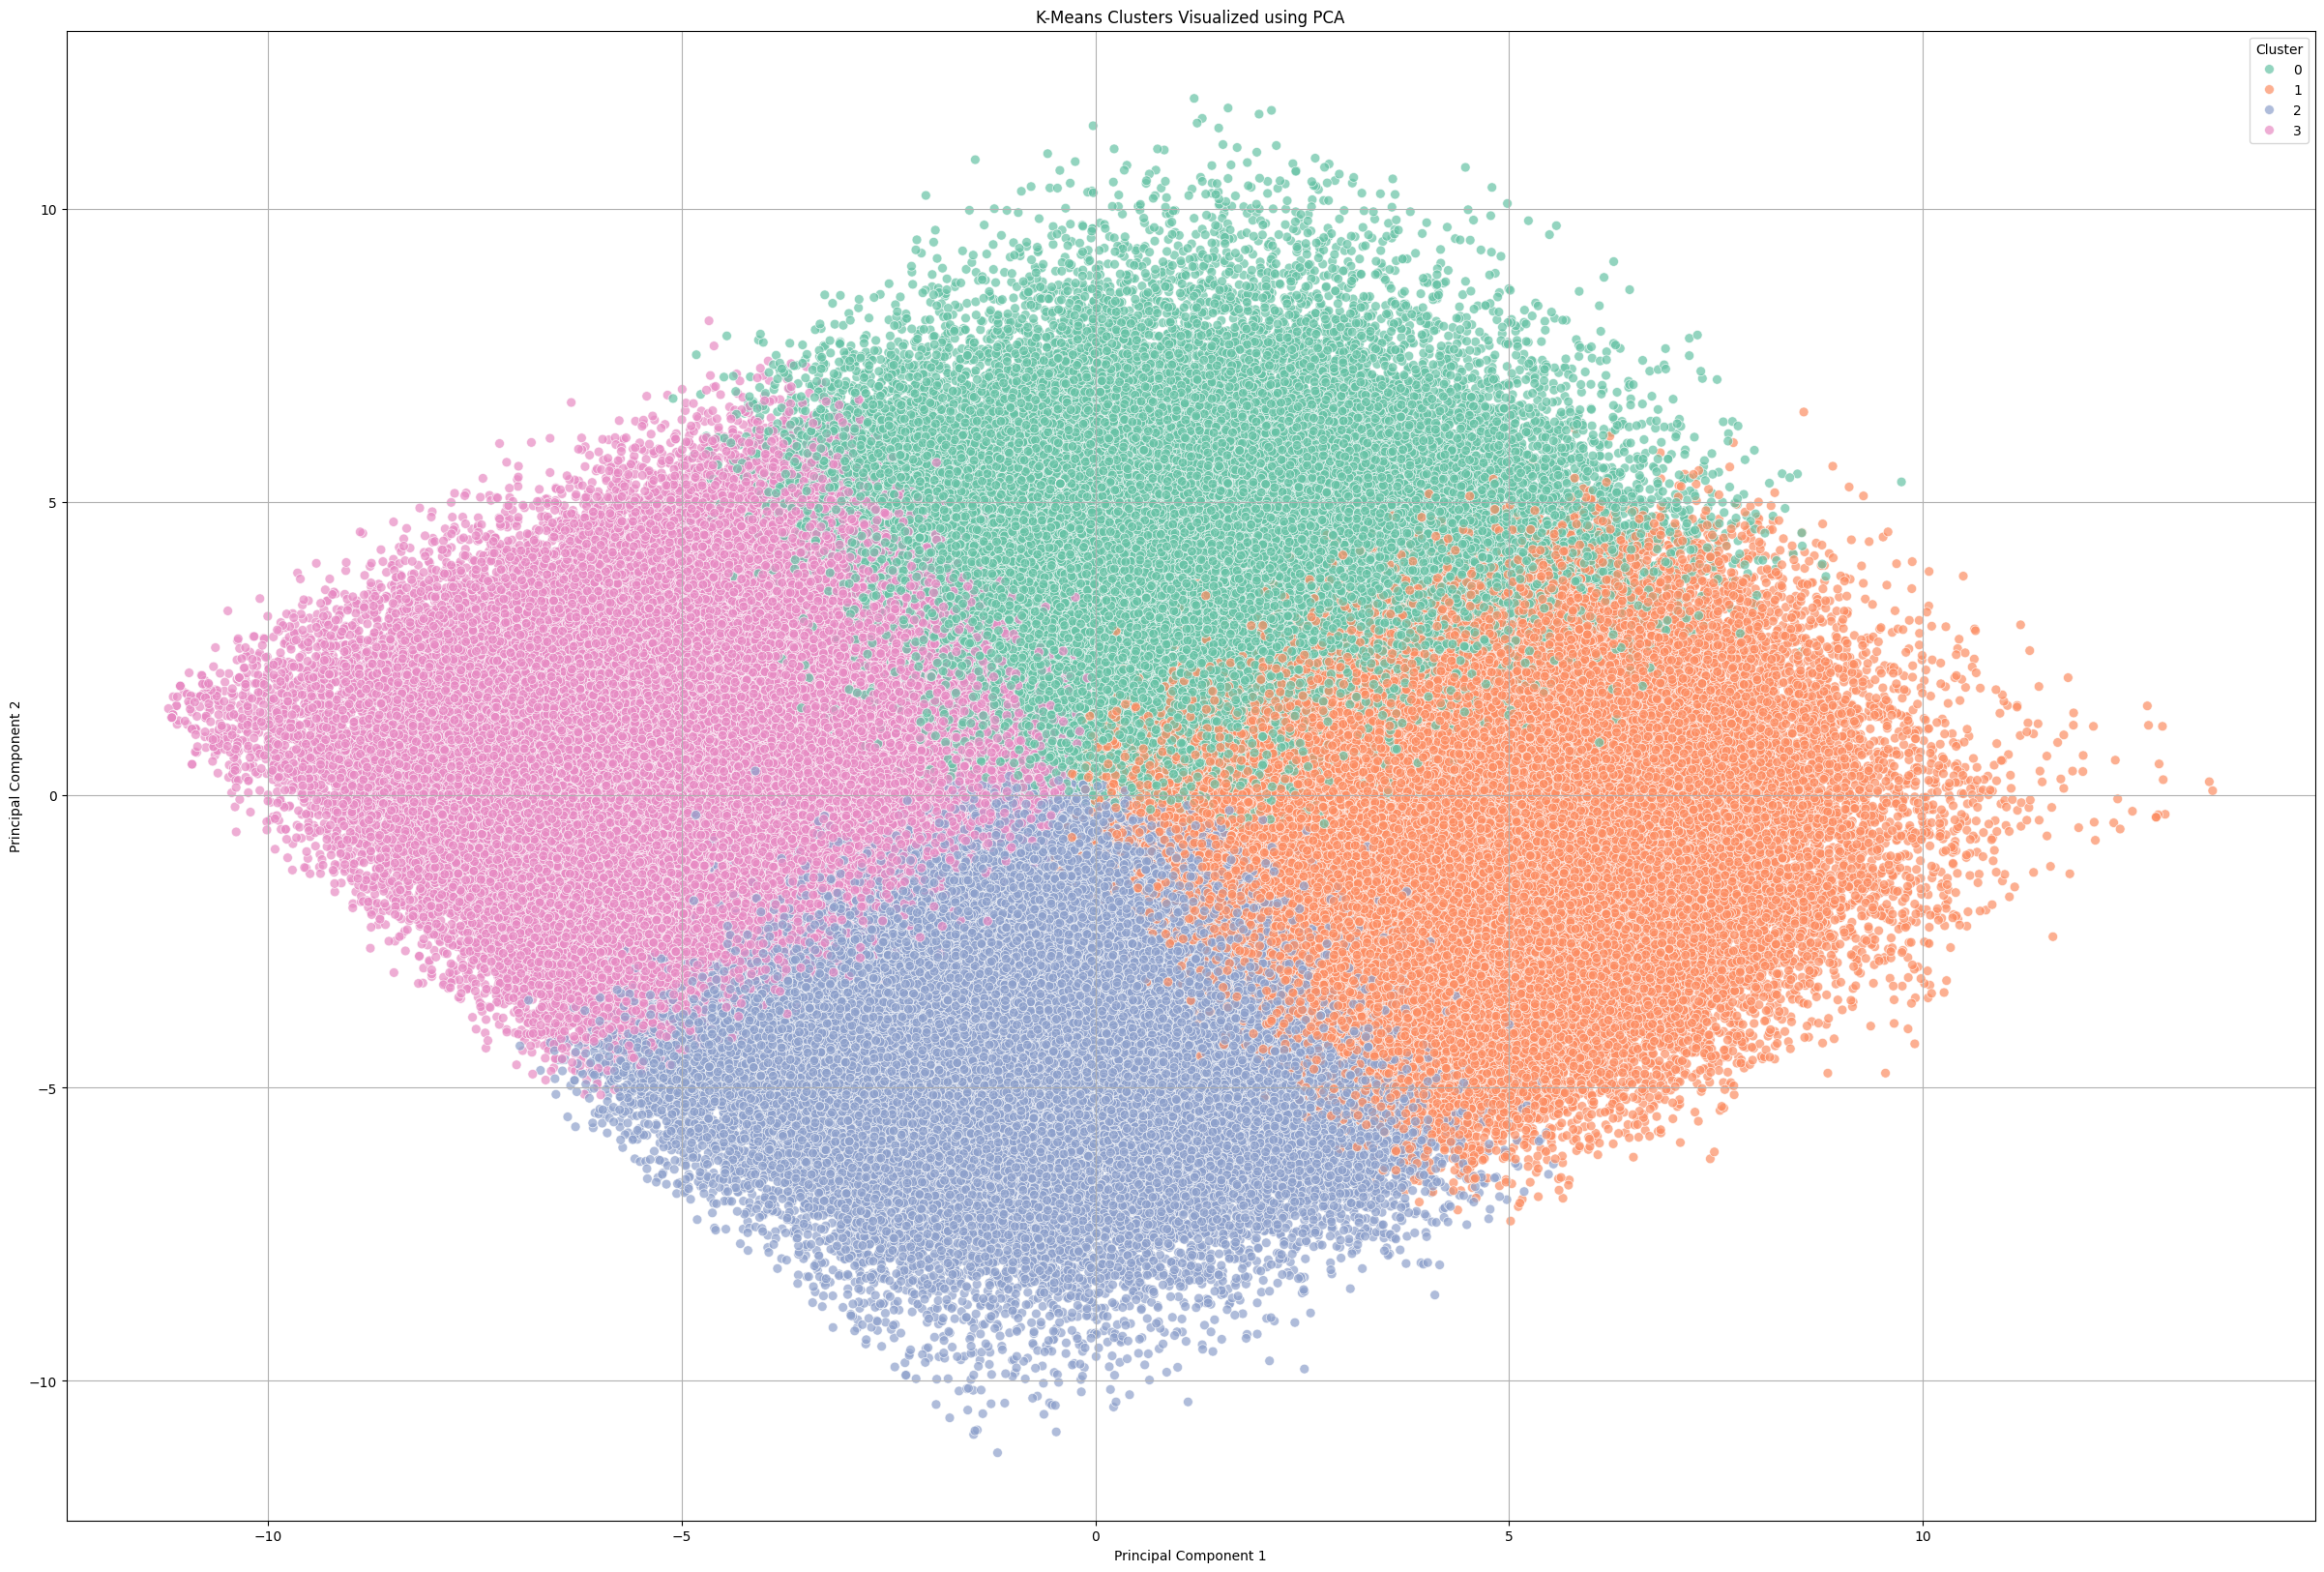

In [ ]:
# Reduce to 2 principal components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

# Plot clusters in 2D
plt.figure(figsize=(30, 20))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=50, alpha=0.7)
plt.title('K-Means Clusters Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# Evaluate
sil = silhouette_score(X, clusters)
db = davies_bouldin_score(X, clusters)
ch = calinski_harabasz_score(X, clusters)

# Save results
evaluation_results.append({
    'Model': 'KMeans',
    'Silhouette': sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch
})

# Clean up
del kmeans, clusters
gc.collect()

4896

### Hierarchical Clustering

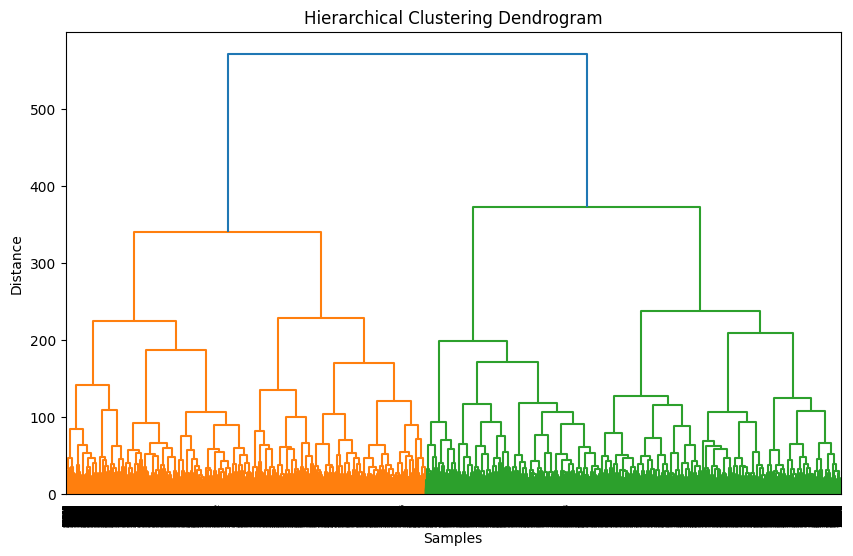

In [ ]:
X_sample = X.sample(n=30000, random_state=42)

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels_agg = agg_cluster.fit_predict(X_sample)

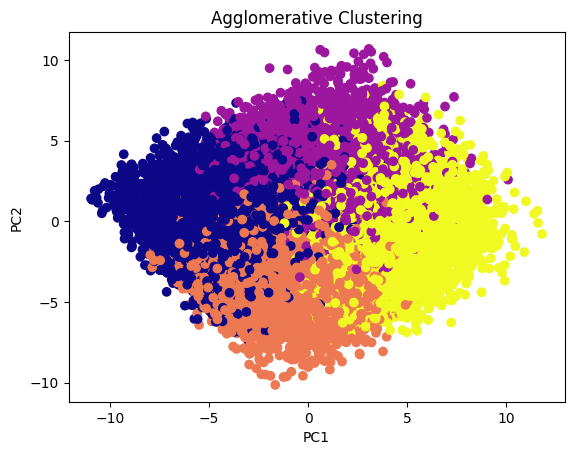

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_sample)
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_agg, cmap='plasma')
plt.title('Agglomerative Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
# Evaluate
sil = silhouette_score(X_sample, labels_agg)
db = davies_bouldin_score(X_sample, labels_agg)
ch = calinski_harabasz_score(X_sample, labels_agg)

# Save results
evaluation_results.append({
    'Model': 'AgglomerativeClustering', # Changed from 'KMeans' to reflect the actual model
    'Silhouette': sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch
})

# Clean up
del agg_cluster, labels_agg, linked, X_sample # Changed 'kmeans' to 'agg_cluster'
gc.collect()

2885261

### DBSCAN

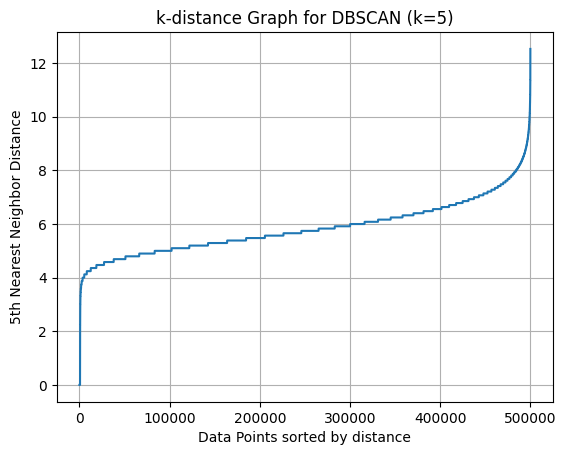

In [ ]:
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

# Sort and plot the 5th nearest neighbor distances
distances = np.sort(distances[:, 4])  # 4 because n_neighbors=5
plt.plot(distances)
plt.title('k-distance Graph for DBSCAN (k=5)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

In [ ]:
# Apply DBSCAN
dbscan = DBSCAN(eps=6.7, min_samples=10, n_jobs=-1)
dbscan_clusters = dbscan.fit_predict(X)
# Add DBSCAN cluster labels to the sample DataFrame
df['DBSCAN_Cluster'] = dbscan_clusters
print(df['DBSCAN_Cluster'].value_counts())

[2025-04-22 15:37:56.883] [CUML] [info] Unused keyword parameter: n_jobs during cuML estimator initialization
[2025-04-22 15:37:57.076] [CUML] [warning] Batch size limited by the chosen integer type (4 bytes). 4983 -> 4294. Using the larger integer type might result in better performance
DBSCAN_Cluster
 0    440430
-1     59570
Name: count, dtype: int64


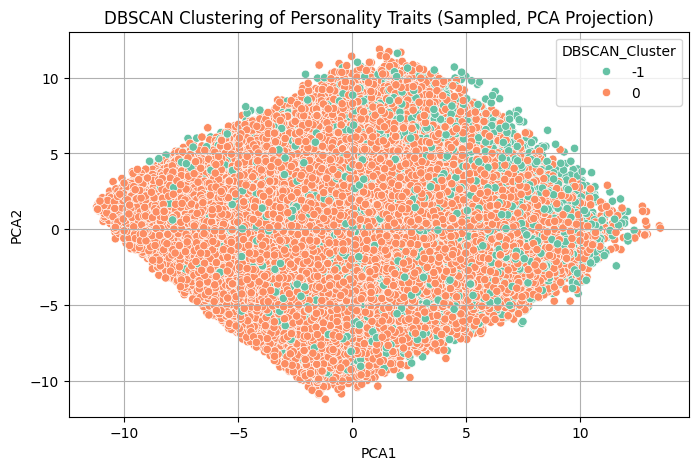

In [ ]:
# PCA for visualization
pca = PCA(n_components=2) # Remove n_jobs=-1
X_pca = pca.fit_transform(X)
#
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='Set2', data=df)
plt.title('DBSCAN Clustering of Personality Traits (Sampled, PCA Projection)')
plt.grid(True)
plt.show()

In [ ]:
n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)

if n_clusters > 1:
    sil = silhouette_score(X, dbscan_clusters)
    db = davies_bouldin_score(X, dbscan_clusters)
    ch = calinski_harabasz_score(X, dbscan_clusters)

    print("DBSCAN Evaluation:")
    print(f"Number of clusters (excluding noise): {n_clusters}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies-Bouldin Score: {db:.4f}")
    print(f"Calinski-Harabasz Index: {ch:.2f}")

    # Optional: Save for comparison
    evaluation_results.append({
        'Model': 'DBSCAN',
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    })
else:
    print(" DBSCAN only found 1 cluster or all noise. Skipping evaluation.")
    evaluation_results.append({
        'Model': 'DBSCAN',
        'Silhouette': None,
        'Davies-Bouldin': None,
        'Calinski-Harabasz': None
    })


 DBSCAN only found 1 cluster or all noise. Skipping evaluation.


In [ ]:
# DBSCAN model and outputs
del dbscan, dbscan_clusters, neigh, nbrs, distances, indices, pca, X_pca

#  done plotting and don't need the PCA columns anymore
df.drop(columns=['PCA1', 'PCA2'], inplace=True, errors='ignore')

# DBSCAN_Cluster is no longer needed (after saving evaluations)
df.drop(columns=['DBSCAN_Cluster'], inplace=True, errors='ignore')

# Garbage collect
gc.collect()

159

<ipython-input-21-7f926289b9d1>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Silhouette', data=df, palette='pastel')


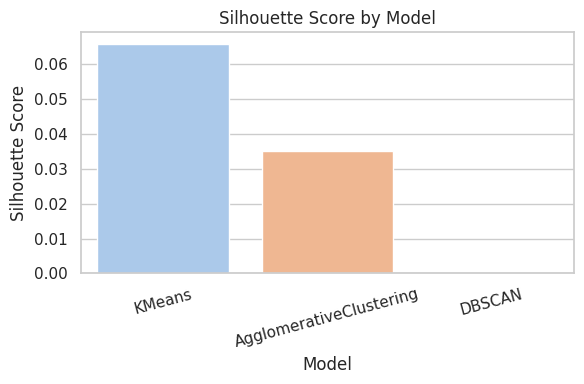

<ipython-input-21-7f926289b9d1>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Davies-Bouldin', data=df, palette='muted')


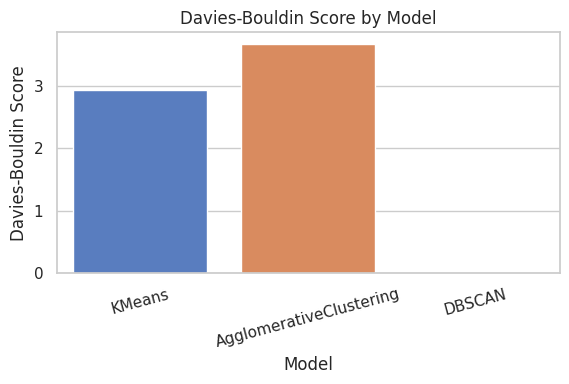

<ipython-input-21-7f926289b9d1>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Calinski-Harabasz', data=df, palette='deep')


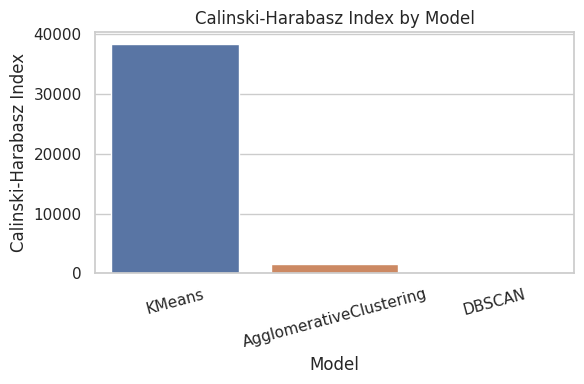

In [ ]:
df = pd.DataFrame(evaluation_results)

# Set plot style
sns.set_theme(style='whitegrid')

# Silhouette Score Plot
plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Silhouette', data=df, palette='pastel')
plt.title('Silhouette Score by Model')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Davies-Bouldin Score Plot (lower is better)
plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Davies-Bouldin', data=df, palette='muted')
plt.title('Davies-Bouldin Score by Model')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Calinski-Harabasz Score Plot (higher is better)
plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Calinski-Harabasz', data=df, palette='deep')
plt.title('Calinski-Harabasz Index by Model')
plt.ylabel('Calinski-Harabasz Index')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()